Training data preview:
   size
0   500
1   700
2   800
3   900
4  1000

Training model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model training complete.

Average loss on test data: 4472.59
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Predictions:
  House size 1300 sq ft → predicted price: $327k
  House size 2100 sq ft → predicted price: $529k
  House size 3500 sq ft → predicted price: $882k
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


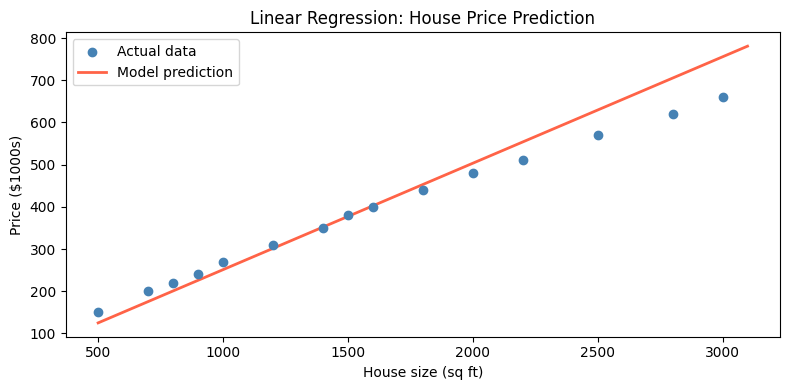

Plot saved as linear_regression.png


In [2]:
# ============================================================
# ALGORITHM 1: LINEAR REGRESSION
# Predict house price based on size (sq ft)
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# --- OUR OWN DATA ---
# House sizes (sq ft) and their prices ($1000s)
house_sizes  = [500, 700, 800, 900, 1000, 1200, 1400, 1500, 1600, 1800,
                2000, 2200, 2500, 2800, 3000]
house_prices = [150, 200, 220, 240, 270,  310,  350,  380,  400,  440,
                480, 510, 570, 620, 660]

df_train = pd.DataFrame({'size': house_sizes[:10], 'price': house_prices[:10]})
df_test  = pd.DataFrame({'size': house_sizes[10:], 'price': house_prices[10:]})

y_train = df_train.pop('price')
y_test  = df_test.pop('price')

print("Training data preview:")
print(df_train.head())

# --- MODEL (using Keras, the modern TF2 way) ---
# Define a simple sequential model for linear regression
model = tf.keras.Sequential([
    # The first layer takes a single input feature ('size') and outputs one value (price)
    tf.keras.layers.Dense(1, input_shape=[1], name='output_layer')
])

# Compile the model: specify optimizer and loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mse') # mse = Mean Squared Error

# --- TRAIN ---
# Keras models train directly on NumPy arrays or tf.data.Dataset objects
# We'll use our Pandas DataFrame columns converted to NumPy arrays
print("\nTraining model...")
history = model.fit(df_train['size'], y_train, epochs=100, verbose=0) # verbose=0 to suppress epoch output
print("Model training complete.")

# --- EVALUATE ---
# Evaluate the model on test data
loss = model.evaluate(df_test['size'], y_test, verbose=0)
print(f"\nAverage loss on test data: {loss:.2f}")

# --- PREDICT ---
# Prepare new data for prediction as a NumPy array
predict_sizes = np.array([1300, 2100, 3500])
predictions = model.predict(predict_sizes) # Keras predict expects a NumPy array

print("\nPredictions:")
for size, pred_array in zip(predict_sizes, predictions):
    print(f"  House size {size} sq ft → predicted price: ${pred_array[0]:.0f}k")

# --- VISUALISE ---
sizes  = np.array(range(500, 3200, 100)) # Convert to NumPy array for Keras predict
# Get predictions for the plot line
line_preds = model.predict(sizes).flatten() # Use flatten() to convert (N,1) to (N,)

plt.figure(figsize=(8, 4))
plt.scatter(house_sizes, house_prices, color='steelblue', label='Actual data', zorder=3)
plt.plot(sizes, line_preds, color='tomato', linewidth=2, label='Model prediction')
plt.xlabel('House size (sq ft)')
plt.ylabel('Price ($1000s)')
plt.title('Linear Regression: House Price Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('linear_regression.png', dpi=120)
plt.show()
print("Plot saved as linear_regression.png")

In [4]:
# ============================================================
# ALGORITHM 2: CLASSIFICATION (Deep Neural Network)
# Predict if a student passes based on study hours + sleep
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

# --- OUR OWN DATA ---
# Columns: study_hours, sleep_hours, passed (0=fail, 1=pass)
data = {
    'study_hours': [1, 2, 1.5, 3, 4, 5, 6, 2, 3, 7, 8, 5, 4, 6, 9, 1, 2, 7, 8, 3],
    'sleep_hours': [4, 3, 5,   4, 5, 6, 7, 3, 4, 7, 8, 5, 4, 6, 8, 3, 4, 7, 8, 3],
    'passed':      [0, 0, 0,   0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0]
}

df = pd.DataFrame(data)
train_df = df.sample(frac=0.75, random_state=42)   # 75% for training
test_df  = df.drop(train_df.index)                  # 25% for testing

y_train = train_df.pop('passed')
y_test  = test_df.pop('passed')

print(f"Training samples: {len(train_df)}, Test samples: {len(test_df)}")

# Prepare data for Keras (convert DataFrames to NumPy arrays)
X_train = train_df[['study_hours', 'sleep_hours']].values
X_test = test_df[['study_hours', 'sleep_hours']].values
y_train_np = y_train.values
y_test_np = y_test.values

# --- MODEL (using Keras, the modern TF2 way) ---
# Define a simple sequential model for binary classification
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(X_train.shape[1],)), # Input shape matches number of features
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification output (probability)
])

# Compile the model: specify optimizer, loss function, and metrics
model.compile(optimizer='adam',
              loss='binary_crossentropy', # Appropriate loss for binary classification
              metrics=['accuracy'])

# --- TRAIN ---
print("\nTraining Keras model...")
history = model.fit(X_train, y_train_np, epochs=100, verbose=0) # Train directly on NumPy arrays
print("Keras Model training complete.")

# --- EVALUATE ---
loss, accuracy = model.evaluate(X_test, y_test_np, verbose=0)
print(f"\nTest Accuracy (Keras): {accuracy*100:.1f}%")

# --- PREDICT new students ---
new_students = pd.DataFrame({
    'study_hours': [1.0, 7.0, 4.0],
    'sleep_hours': [3.0, 8.0, 4.0]
})

new_students_np = new_students[['study_hours', 'sleep_hours']].values
predictions_keras = model.predict(new_students_np) # Keras predict returns probabilities

print("\nPredictions for new students (Keras):")
for i, pred_prob in enumerate(predictions_keras):
    predicted_class = 1 if pred_prob[0] > 0.5 else 0 # Convert probability to class
    label    = "PASS ✓" if predicted_class == 1 else "FAIL ✗"
    conf     = pred_prob[0] * 100 if predicted_class == 1 else (1 - pred_prob[0]) * 100 # Confidence for predicted class
    print(f"  Student {i+1} | Study: {new_students['study_hours'][i]}h, "
          f"Sleep: {new_students['sleep_hours'][i]}h → {label} ({conf:.0f}% confident)")

Training samples: 15, Test samples: 5

Training Keras model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras Model training complete.

Test Accuracy (Keras): 60.0%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

Predictions for new students (Keras):
  Student 1 | Study: 1.0h, Sleep: 3.0h → PASS ✓ (50% confident)
  Student 2 | Study: 7.0h, Sleep: 8.0h → PASS ✓ (70% confident)
  Student 3 | Study: 4.0h, Sleep: 4.0h → PASS ✓ (58% confident)


Customer data sample:
    age  spending_score
0  26.5            27.3
1  24.6            18.9
2  26.9            20.3
3  29.6            12.9
4  24.3            17.3

Total customers: 60


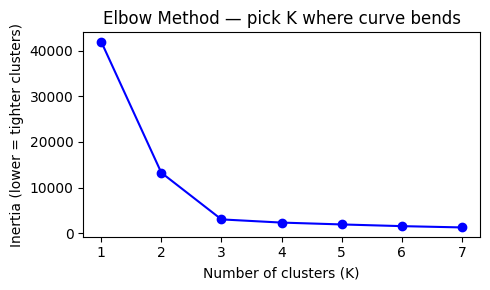


Cluster centres (average age & spending per group):
          age  spending_score
cluster                      
0        58.4            45.8
1        24.5            18.7
2        39.4            71.8


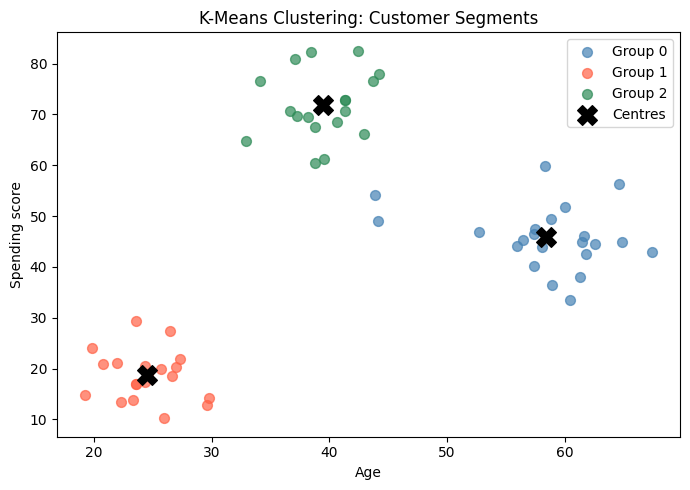


New customer (age=35, spending=65) → belongs to Group 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [5]:
# ============================================================
# ALGORITHM 3: K-MEANS CLUSTERING
# Group customers by age and spending score
# (TF's KMeans has bugs, so we use sklearn — same concept!)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- OUR OWN DATA ---
np.random.seed(42)

# Simulate 3 types of customers
young_low    = np.column_stack([np.random.normal(25, 3, 20), np.random.normal(20, 5, 20)])
middle_high  = np.column_stack([np.random.normal(40, 4, 20), np.random.normal(70, 8, 20)])
senior_mid   = np.column_stack([np.random.normal(60, 5, 20), np.random.normal(45, 6, 20)])

customers = np.vstack([young_low, middle_high, senior_mid])
df = pd.DataFrame(customers, columns=['age', 'spending_score'])

print("Customer data sample:")
print(df.head(5).round(1))
print(f"\nTotal customers: {len(df)}")

# --- FIND BEST K using Elbow Method ---
inertias = []
k_range  = range(1, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df)
    inertias.append(km.inertia_)

plt.figure(figsize=(5, 3))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method — pick K where curve bends')
plt.tight_layout()
plt.savefig('elbow.png', dpi=120)
plt.show()

# --- RUN K-MEANS with K=3 ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df)

print("\nCluster centres (average age & spending per group):")
print(df.groupby('cluster').mean().round(1))

# --- VISUALISE ---
colors = ['steelblue', 'tomato', 'seagreen']
plt.figure(figsize=(7, 5))
for cluster_id in range(3):
    subset = df[df['cluster'] == cluster_id]
    plt.scatter(subset['age'], subset['spending_score'],
                c=colors[cluster_id], label=f'Group {cluster_id}', alpha=0.7, s=50)

centres = kmeans.cluster_centers_
plt.scatter(centres[:, 0], centres[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centres')

plt.xlabel('Age')
plt.ylabel('Spending score')
plt.title('K-Means Clustering: Customer Segments')
plt.legend()
plt.tight_layout()
plt.savefig('clustering.png', dpi=120)
plt.show()

# --- Predict which group a new customer belongs to ---
new_customer = [[35, 65]]
group = kmeans.predict(new_customer)[0]
print(f"\nNew customer (age=35, spending=65) → belongs to Group {group}")

In [7]:
# ============================================================
# ALGORITHM 4: HIDDEN MARKOV MODEL
# Predict temperature given hidden weather states
# ============================================================

import tensorflow_probability as tfp
import tensorflow as tf
import numpy as np

tfd = tfp.distributions

# --- THE MODEL (same as your notes, explained line by line) ---

# INITIAL probabilities: day 1 is 80% cold, 20% hot
initial_dist = tfd.Categorical(probs=[0.8, 0.2])

# TRANSITION probabilities:
#   if cold today → 70% cold tomorrow, 30% hot tomorrow
#   if hot today  → 20% cold tomorrow, 80% hot tomorrow
transition_dist = tfd.Categorical(probs=[[0.7, 0.3],
                                         [0.2, 0.8]])

# OBSERVATION probabilities:
#   cold day: temperature is normal(mean=0,  std=5)
#   hot day:  temperature is normal(mean=15, std=10)
observation_dist = tfd.Normal(loc=[0., 15.], scale=[5., 10.])

# --- BUILD THE HMM ---
model = tfd.HiddenMarkovModel(
    initial_distribution=initial_dist,    # CORRECTED: Was transition_dist
    transition_distribution=transition_dist,
    observation_distribution=observation_dist,
    num_steps=7    # predict 1 week (7 days)
)

# --- PREDICT expected temperature for each of the 7 days ---
mean_temps = model.mean()

# Under TF 2, we may need to evaluate inside a session or use numpy
mean_temps_numpy = tf.identity(mean_temps).numpy()

print("Expected temperature for each day of the week:")
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for day, temp in zip(days, mean_temps_numpy):
    bar = '█' * int((temp + 5) / 1.5)   # simple text bar chart
    print(f"  {day}: {temp:5.1f}°C  {bar}")

# --- SAMPLE: simulate what one actual week might look like ---
print("\nOne simulated week of temperatures:")
sample = model.sample().numpy()
for day, temp in zip(days, sample):
    state = "🔥 hot" if temp > 10 else "❄️  cold"
    print(f"  {day}: {temp:5.1f}°C  ({state})")

# --- TRY DIFFERENT starting conditions ---
print("\nWhat if we start with 50/50 chance of hot or cold?")
initial_5050 = tfd.Categorical(probs=[0.5, 0.5])
model2 = tfd.HiddenMarkovModel(
    initial_distribution=initial_5050,
    transition_distribution=transition_dist,
    observation_distribution=observation_dist,
    num_steps=7
)
temps2 = model2.mean().numpy()
for day, temp in zip(days, temps2):
    print(f"  {day}: {temp:.1f}°C")

Expected temperature for each day of the week:
  Mon:   3.0°C  █████
  Tue:   6.0°C  ███████
  Wed:   7.5°C  ████████
  Thu:   8.2°C  ████████
  Fri:   8.6°C  █████████
  Sat:   8.8°C  █████████
  Sun:   8.9°C  █████████

One simulated week of temperatures:
  Mon:  32.7°C  (🔥 hot)
  Tue:  11.2°C  (🔥 hot)
  Wed:  10.2°C  (🔥 hot)
  Thu:   1.9°C  (❄️  cold)
  Fri:   9.0°C  (❄️  cold)
  Sat:   6.2°C  (❄️  cold)
  Sun:  12.8°C  (🔥 hot)

What if we start with 50/50 chance of hot or cold?
  Mon: 7.5°C
  Tue: 8.2°C
  Wed: 8.6°C
  Thu: 8.8°C
  Fri: 8.9°C
  Sat: 9.0°C
  Sun: 9.0°C
